In [ ]:
import requests
import os
import time
import pandas as pd
import random
from tqdm import tqdm

# ========================
# ACCESS TOKEN
# ========================
ACCESS_TOKEN = "XXX"

# ========================
# BOUNDING BOXES
# ========================
BBOXES = [
    "55.270,25.190,55.300,25.220",  # Dubai Downtown
    "55.300,25.260,55.330,25.290",  # Deira
    "55.370,25.300,55.400,25.330",  # Sharjah Residential
    "55.420,25.310,55.450,25.340",  # Al Quoz Industrial
    "55.280,25.230,55.310,25.260",  # Zabeel/Mankhool Parks
    "55.315,25.270,55.330,25.285",  # Rigga
    "55.380,25.330,55.395,25.345",  # Majaz
    "55.350,25.330,55.365,25.345",  # Al Khan
    "55.470,25.405,55.490,25.425",  # Ajman
    "54.430,24.500,54.450,24.520",  # Reem Island
]

# ========================
# SETTINGS
# ========================
MAX_PER_BBOX = 200  # images per area

# ========================
# OUTPUT
# ========================
os.makedirs("dataset/images", exist_ok=True)

metadata_list = []
downloaded_ids = set()

# ========================
# MAIN LOOP
# ========================
for bbox in BBOXES:
    print(f"\nProcessing bbox: {bbox}")
    
    url = f"https://graph.mapillary.com/images?bbox={bbox}&fields=id,thumb_2048_url,computed_geometry&access_token={ACCESS_TOKEN}"
    
    all_images = []

    # Collect all images (metadata only first)
    while url:
        response = requests.get(url).json()
        images = response.get("data", [])
        all_images.extend(images)
        url = response.get("paging", {}).get("next")
        time.sleep(0.3)

    print(f"Total available: {len(all_images)}")

    # Random sampling
    sampled_images = random.sample(all_images, min(len(all_images), MAX_PER_BBOX))
    
    print(f"Downloading: {len(sampled_images)} images")

    # Download images
    for img in tqdm(sampled_images):
        img_id = img["id"]

        if img_id in downloaded_ids:
            continue

        downloaded_ids.add(img_id)

        img_url = img.get("thumb_2048_url")
        geometry = img.get("computed_geometry", {})

        if not img_url:
            continue

        try:
            img_data = requests.get(img_url).content

            with open(f"C:/Users/hp/Desktop/New folder (2)/Desktop/University/Current Courses/COE486/proj/mapillary_images/{img_id}.jpg", "wb") as f:
                f.write(img_data)

            coords = geometry.get("coordinates", [None, None])

            metadata_list.append({
                "image_id": img_id,
                "longitude": coords[0],
                "latitude": coords[1],
                "bbox": bbox
            })

        except:
            continue

# ========================
# SAVE METADATA
# ========================
df = pd.DataFrame(metadata_list)
df.to_csv("dataset/metadata.csv", index=False)

print("\n✅ Done!")
print(f"Total images downloaded: {len(downloaded_ids)}")


Processing bbox: 55.270,25.190,55.300,25.220
Total available: 1576
Downloading: 200 images


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [04:28<00:00,  1.34s/it]



Processing bbox: 55.300,25.260,55.330,25.290
Total available: 1839
Downloading: 200 images


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [06:31<00:00,  1.96s/it]



Processing bbox: 55.370,25.300,55.400,25.330
Total available: 1921
Downloading: 200 images


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [03:59<00:00,  1.20s/it]



Processing bbox: 55.420,25.310,55.450,25.340
Total available: 1756
Downloading: 200 images


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [05:27<00:00,  1.64s/it]



Processing bbox: 55.280,25.230,55.310,25.260
Total available: 1813
Downloading: 200 images


 64%|███████████████████████████████████████████████████▏                            | 128/200 [02:22<01:22,  1.15s/it]

In [28]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
)

id2label = model.config.id2label

for i, label in id2label.items():
    print(i, label)

config.json: 0.00B [00:00, ?B/s]

C:\Users\hp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--nvidia--segformer-b2-finetuned-ade-512-512. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

0 wall
1 building
2 sky
3 floor
4 tree
5 ceiling
6 road
7 bed 
8 windowpane
9 grass
10 cabinet
11 sidewalk
12 person
13 earth
14 door
15 table
16 mountain
17 plant
18 curtain
19 chair
20 car
21 water
22 painting
23 sofa
24 shelf
25 house
26 sea
27 mirror
28 rug
29 field
30 armchair
31 seat
32 fence
33 desk
34 rock
35 wardrobe
36 lamp
37 bathtub
38 railing
39 cushion
40 base
41 box
42 column
43 signboard
44 chest of drawers
45 counter
46 sand
47 sink
48 skyscraper
49 fireplace
50 refrigerator
51 grandstand
52 path
53 stairs
54 runway
55 case
56 pool table
57 pillow
58 screen door
59 stairway
60 river
61 bridge
62 bookcase
63 blind
64 coffee table
65 toilet
66 flower
67 book
68 hill
69 bench
70 countertop
71 stove
72 palm
73 kitchen island
74 computer
75 swivel chair
76 boat
77 bar
78 arcade machine
79 hovel
80 bus
81 towel
82 light
83 truck
84 tower
85 chandelier
86 awning
87 streetlight
88 booth
89 television receiver
90 airplane
91 dirt track
92 apparel
93 pole
94 land
95 bannister
96

In [ ]:
import torch
import numpy as np
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

IMAGE_DIR   = "C:/Users/hp/Desktop/New folder (2)/Desktop/University/Current Courses/COE486/proj/mapillary_images_postfiltering"
METADATA    = "C:/Users/hp/dataset/metadata.csv"  
OUTPUT_CSV  = "C:/Users/hp/dataset/scores.csv"

ADE20K_CLASSES = {
    "sidewalk":  11,   # "sidewalk"
    "tree":       4,   # "tree"
    "grass":      9,   # "grass"
    "plant":      17,  # "plant"
    "palm":       72,  # "palm tree"
    "fence":      32,  # "fence"
}

SIDEWALK_IDS    = {ADE20K_CLASSES["sidewalk"]}
VEGETATION_IDS  = {ADE20K_CLASSES["tree"], ADE20K_CLASSES["grass"],
                   ADE20K_CLASSES["plant"], ADE20K_CLASSES["palm"]}
OBSTRUCTION_IDS = {ADE20K_CLASSES["fence"]}

# ========================
# LOAD MODEL
# ========================
print("Loading SegFormer...")
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b2-finetuned-ade-512-512") #prepare images (resize, normalize, tensor)
model     = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b2-finetuned-ade-512-512")
model.eval()
device = "cpu"
model.to(device)

# ========================
# SCORING FUNCTION
# ========================
def compute_scores(seg_map):
    """seg_map: 2D numpy array of ADE20K class indices"""
    total = seg_map.size
    r_sidewalk = np.isin(seg_map, list(SIDEWALK_IDS)).sum() / total
    r_veg      = np.isin(seg_map, list(VEGETATION_IDS)).sum() / total
    r_obs      = np.isin(seg_map, list(OBSTRUCTION_IDS)).sum() / total
    raw = 0.6 * r_sidewalk + 0.4 * r_veg - 1.5 * r_obs
    return r_sidewalk, r_veg, r_obs, raw

# ========================
# MAIN LOOP
# ========================
df_meta = pd.read_csv(METADATA)
results = []

for fname in tqdm(os.listdir(IMAGE_DIR)):
    if not fname.endswith(".jpg"):
        continue
    image_id = fname.replace(".jpg", "")
    img_path = os.path.join(IMAGE_DIR, fname)

    try:
        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        # Upsample logits to original image size
        upsampled = torch.nn.functional.interpolate(
            outputs.logits,
            size=image.size[::-1],  # (height, width)
            mode="bilinear",
            align_corners=False
        )
        seg_map = upsampled.argmax(dim=1).squeeze().cpu().numpy()

        r_sw, r_veg, r_obs, raw = compute_scores(seg_map)

        results.append({
            "image_id":       image_id,
            "r_sidewalk":     round(r_sw, 4),
            "r_vegetation":   round(r_veg, 4),
            "r_obstruction":  round(r_obs, 4),
            "raw_score":      round(raw, 4),
        })

    except Exception as e:
        print(f"Failed: {fname} — {e}")

# ========================
# NORMALIZE + SAVE
# ========================
df_scores = pd.DataFrame(results)

# Min-max normalize raw_score
mn, mx = df_scores["raw_score"].min(), df_scores["raw_score"].max()
df_scores["walkability"] = ((df_scores["raw_score"] - mn) / (mx - mn)).round(4)

In [40]:
# Save
df_scores["image_id"] = df_scores["image_id"].astype(str)
df_meta["image_id"]   = df_meta["image_id"].astype(str)

mn, mx = df_scores["raw_score"].min(), df_scores["raw_score"].max()
df_scores["walkability"] = ((df_scores["raw_score"] - mn) / (mx - mn)).round(4)

df_final = pd.merge(df_scores, df_meta[["image_id", "longitude", "latitude", "bbox"]],
                    on="image_id", how="left")

df_final.to_csv(OUTPUT_CSV, index=False)
print(f"Done. Saved to {OUTPUT_CSV}")
print(df_final.describe())

Done. Saved to C:/Users/hp/dataset/scores.csv
        r_sidewalk  r_vegetation  r_obstruction    raw_score  walkability  \
count  1019.000000   1019.000000    1019.000000  1019.000000  1019.000000   
mean      0.083714      0.114104       0.005380     0.087798     0.521006   
std       0.120411      0.121264       0.014811     0.094130     0.158202   
min       0.000000      0.000000       0.000000    -0.222200     0.000000   
25%       0.000250      0.015200       0.000000     0.021600     0.409750   
50%       0.025400      0.078200       0.000000     0.061800     0.477300   
75%       0.103050      0.165750       0.002000     0.147850     0.621950   
max       0.556200      0.598200       0.180300     0.372800     1.000000   

         longitude     latitude  
count  1018.000000  1018.000000  
mean     55.321569    25.273183  
std       0.204314     0.175202  
min      54.337712    24.470047  
25%      55.313787    25.249331  
50%      55.360530    25.323409  
75%      55.383901    

In [1]:
# Aggregate scores
import pandas as pd

df = pd.read_csv("C:/Users/hp/dataset/scores.csv")

area_labels = {
    "55.270,25.190,55.300,25.220": "Dubai Downtown",
    "55.300,25.260,55.330,25.290": "Deira",
    "55.370,25.300,55.400,25.330": "Sharjah Residential",
    "55.420,25.310,55.450,25.340": "Industrial",
    "55.280,25.230,55.310,25.260": "Park",
    "55.315,25.270,55.330,25.285": "Rigga",
    "55.380,25.330,55.395,25.345": "Majaz",
    "55.350,25.330,55.365,25.345": "Al Khan",
    "55.470,25.405,55.490,25.425": "Ajman",
    "54.430,24.500,54.450,24.520": "Reem Island"
}

df["area"] = df["bbox"].map(area_labels)

summary = df.groupby("area").agg(
    n_images       = ("image_id",    "count"),
    avg_sidewalk   = ("r_sidewalk",  "mean"),
    avg_vegetation = ("r_vegetation","mean"),
    avg_obstruction= ("r_obstruction","mean"),
    avg_walkability= ("walkability", "mean"),
    std_walkability= ("walkability", "std"),
).reset_index().round(4)

summary = summary.sort_values("avg_walkability", ascending=False)
print(summary.to_string(index=False))
summary.to_csv("dataset/area_summary.csv", index=False)

               area  n_images  avg_sidewalk  avg_vegetation  avg_obstruction  avg_walkability  std_walkability
              Rigga        53        0.0591          0.2268           0.0007           0.5839           0.1267
              Majaz        16        0.1184          0.0874           0.0051           0.5389           0.1401
            Al Khan       189        0.0841          0.1223           0.0031           0.5327           0.1604
              Deira        92        0.1176          0.0514           0.0028           0.5196           0.1364
     Dubai Downtown       118        0.1033          0.0694           0.0075           0.5054           0.1717
Sharjah Residential        56        0.0899          0.0902           0.0098           0.5000           0.1813
              Ajman       157        0.0098          0.1394           0.0044           0.4659           0.0970
         Industrial        46        0.0111          0.1378           0.0073           0.4590           0.1091
 

In [5]:
import folium
import pandas as pd

areas = {
    "Rigga":               {"lat": 25.260, "lon": 55.330, "avg_walkability": 0.5839, "avg_sidewalk": 0.0591, "avg_vegetation": 0.2268, "n_images": 53},
    "Majaz":               {"lat": 25.350, "lon": 55.390, "avg_walkability": 0.5389, "avg_sidewalk": 0.1184, "avg_vegetation": 0.0874, "n_images": 16},
    "Al Khan":             {"lat": 25.330, "lon": 55.370, "avg_walkability": 0.5327, "avg_sidewalk": 0.0841, "avg_vegetation": 0.1223, "n_images": 189},
    "Deira":               {"lat": 25.275, "lon": 55.315, "avg_walkability": 0.5196, "avg_sidewalk": 0.1176, "avg_vegetation": 0.0514, "n_images": 92},
    "Dubai Downtown":      {"lat": 25.205, "lon": 55.285, "avg_walkability": 0.5054, "avg_sidewalk": 0.1033, "avg_vegetation": 0.0694, "n_images": 118},
    "Sharjah Residential": {"lat": 25.315, "lon": 55.385, "avg_walkability": 0.5000, "avg_sidewalk": 0.0899, "avg_vegetation": 0.0902, "n_images": 56},
    "Ajman":               {"lat": 25.405, "lon": 55.435, "avg_walkability": 0.4659, "avg_sidewalk": 0.0098, "avg_vegetation": 0.1394, "n_images": 157},
    "Industrial":          {"lat": 25.325, "lon": 55.435, "avg_walkability": 0.4590, "avg_sidewalk": 0.0111, "avg_vegetation": 0.1378, "n_images": 46},
    "Park":                {"lat": 25.245, "lon": 55.295, "avg_walkability": 0.4433, "avg_sidewalk": 0.0246, "avg_vegetation": 0.0947, "n_images": 34},
    "Reem Island":         {"lat": 24.490, "lon": 54.390, "avg_walkability": 0.4371, "avg_sidewalk": 0.0128, "avg_vegetation": 0.0957, "n_images": 18},
}

def score_to_color(score):
    if score >= 0.53:
        return "green"
    elif score >= 0.47:
        return "orange"
    else:
        return "red"

# Reem Island is in Abu Dhabi so center map to fit all points
m = folium.Map(location=[25.10, 55.20], zoom_start=9, tiles="CartoDB positron")

for area, data in areas.items():
    color = score_to_color(data["avg_walkability"])

    popup_html = f"""
    <b>{area}</b><br>
    Walkability: <b>{data['avg_walkability']:.3f}</b><br>
    Sidewalk coverage: {data['avg_sidewalk']:.3f}<br>
    Vegetation coverage: {data['avg_vegetation']:.3f}<br>
    Images: {data['n_images']}
    """

    folium.CircleMarker(
        location=[data["lat"], data["lon"]],
        radius=20,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{area}: {data['avg_walkability']:.3f}"
    ).add_to(m)

    folium.Marker(
        location=[data["lat"], data["lon"]],
        icon=folium.DivIcon(
            html=f'<div style="font-size:9px; font-weight:bold; color:white; text-align:center; margin-top:6px;">{data["avg_walkability"]:.2f}</div>',
            icon_size=(40, 20),
            icon_anchor=(20, 10)
        )
    ).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>Walkability Score</b><br>
  <span style="color:green">●</span> High  (≥ 0.53)<br>
  <span style="color:orange">●</span> Medium (0.47–0.53)<br>
  <span style="color:red">●</span> Low   (< 0.47)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("walkability_map.html")
print("Saved to walkability_map.html")
m

Saved to walkability_map.html


In [6]:
import osmnx as ox

# Test on one area first
bbox = (55.300, 25.260, 55.330, 25.290)  # Deira
G = ox.graph_from_bbox(bbox=bbox, network_type='walk')
edges = ox.graph_to_gdfs(G, nodes=False)

print(edges.columns.tolist())

['osmid', 'highway', 'lanes', 'name', 'oneway', 'ref', 'reversed', 'length', 'maxspeed', 'geometry', 'service', 'junction', 'access', 'bridge', 'tunnel']


In [8]:
import osmnx as ox

bbox = (55.300, 25.260, 55.330, 25.290)  # Deira as a test
G = ox.graph_from_bbox(bbox=bbox, network_type='walk')
edges = ox.graph_to_gdfs(G, nodes=False)

# Flatten since some values are lists
highway_values = edges["highway"].explode().value_counts()
print(highway_values)

highway
residential       4448
service           4022
footway           3946
secondary          778
tertiary           706
primary            496
unclassified       184
primary_link       124
secondary_link      72
pedestrian          50
tertiary_link       34
steps               28
living_street        2
Name: count, dtype: int64


In [10]:
import osmnx as ox

bbox = (55.300, 25.260, 55.330, 25.290)  # Deira as test

# ── Check vegetation tag values ────────────────────────────────────
veg_tags = {"landuse": True, "natural": True, "leisure": True}
veg = ox.features_from_bbox(bbox=bbox, tags=veg_tags)

print("=== LANDUSE ===")
if "landuse" in veg.columns:
    print(veg["landuse"].explode().value_counts())

print("\n=== NATURAL ===")
if "natural" in veg.columns:
    print(veg["natural"].explode().value_counts())

print("\n=== LEISURE ===")
if "leisure" in veg.columns:
    print(veg["leisure"].explode().value_counts())

# ── Check barrier tag values ───────────────────────────────────────
barrier_tags = {"barrier": True}
barriers = ox.features_from_bbox(bbox=bbox, tags=barrier_tags)

print("\n=== BARRIER ===")
if "barrier" in barriers.columns:
    print(barriers["barrier"].explode().value_counts())

=== LANDUSE ===
landuse
grass            51
village_green     8
commercial        4
flowerbed         4
residential       3
construction      2
landfill          2
cemetery          1
religious         1
retail            1
industrial        1
Name: count, dtype: int64

=== NATURAL ===
natural
tree                      118
sand                        6
water                       4
coastline                   4
Money Counting Machine      1
organic_products            1
peninsula                   1
bay                         1
Name: count, dtype: int64

=== LEISURE ===
leisure
garden            31
park              14
pitch              9
fitness_centre     6
swimming_pool      4
marina             4
sauna              2
playground         2
Billiards,_PS3     1
golf_course        1
Name: count, dtype: int64

=== BARRIER ===
barrier
gate              37
lift_gate         27
wall               8
hedge              6
sliding_gate       5
jersey_barrier     5
fence              4
block 

In [12]:
import osmnx as ox
import pandas as pd

# bbox tuple is (left, bottom, right, top) = (west, south, east, north)
BBOXES = {
    "Dubai Downtown":      (55.270, 25.190, 55.300, 25.220),
    "Deira":               (55.300, 25.260, 55.330, 25.290),
    "Sharjah Residential": (55.370, 25.300, 55.400, 25.330),
    "Industrial":          (55.420, 25.310, 55.450, 25.340),
    "Park":                (55.280, 25.230, 55.310, 25.260),
    "Rigga":               (55.315, 25.270, 55.330, 25.285),
    "Majaz":               (55.380, 25.330, 55.395, 25.345),
    "Al Khan":             (55.350, 25.330, 55.365, 25.345),
    "Ajman":               (55.470, 25.405, 55.490, 25.425),
    "Reem Island":         (54.430, 24.500, 54.450, 24.520),
}

coverage_results = []

for area, bbox in BBOXES.items():
    print(f"\nChecking {area}...")
    row = {"area": area}

    # ── Sidewalk coverage via highway tags ────────────────────────────
    try:
        G = ox.graph_from_bbox(bbox=bbox, network_type='walk')
        edges = ox.graph_to_gdfs(G, nodes=False)
        total_edges = len(edges)
    
        pedestrian_tags = ["footway", "path", "pedestrian", "steps"]
        tagged = edges["highway"].apply(
            lambda x: any(tag in (x if isinstance(x, list) else [x]) 
                          for tag in pedestrian_tags)
        )
        row["total_walk_edges"]    = total_edges
        row["sidewalk_tagged"]     = int(tagged.sum())
        row["sidewalk_coverage_%"] = round(tagged.sum() / total_edges * 100, 1)
        print(f"  ✓ Walk edges: {total_edges}, Pedestrian-tagged: {int(tagged.sum())}")
    
    except Exception as e:
        print(f"  ✗ Walk graph failed: {e}")
        row["total_walk_edges"]    = None
        row["sidewalk_tagged"]     = None
        row["sidewalk_coverage_%"] = None

    # ── Vegetation coverage ────────────────────────────────────────────
    try:
        veg_tags = {
            "landuse": ["grass", "village_green", "flowerbed"],
            "natural": ["tree"],
            "leisure": ["garden", "park"]
        }
        veg = ox.features_from_bbox(bbox=bbox, tags=veg_tags)
        row["vegetation_features"] = len(veg)
        print(f"  ✓ Vegetation features: {len(veg)}")

    except Exception as e:
        print(f"  ✗ Vegetation query failed: {e}")
        row["vegetation_features"] = None

    # ── Barrier/fence coverage ─────────────────────────────────────────
    try:
        barrier_tags = {
            "barrier": ["wall", "fence", "hedge", "jersey_barrier", "block"]
        }
        barriers = ox.features_from_bbox(bbox=bbox, tags=barrier_tags)
        row["barrier_features"] = len(barriers)
        print(f"  ✓ Barrier features: {len(barriers)}")

    except Exception as e:
        print(f"  ✗ Barrier query failed: {e}")
        row["barrier_features"] = None

    coverage_results.append(row)

df_coverage = pd.DataFrame(coverage_results)
print("\n")
print(df_coverage.to_string(index=False))
df_coverage.to_csv("dataset/osm_coverage.csv", index=False)
print("\nSaved to dataset/osm_coverage.csv")


Checking Dubai Downtown...
  ✓ Walk edges: 10032, Pedestrian-tagged: 2668
  ✓ Vegetation features: 727
  ✓ Barrier features: 48

Checking Deira...
  ✓ Walk edges: 14802, Pedestrian-tagged: 3994
  ✓ Vegetation features: 226
  ✓ Barrier features: 26

Checking Sharjah Residential...
  ✓ Walk edges: 8922, Pedestrian-tagged: 2272
  ✓ Vegetation features: 667
  ✓ Barrier features: 34

Checking Industrial...
  ✓ Walk edges: 6608, Pedestrian-tagged: 652
  ✓ Vegetation features: 42
  ✓ Barrier features: 39

Checking Park...
  ✓ Walk edges: 15544, Pedestrian-tagged: 4498
  ✓ Vegetation features: 658
  ✓ Barrier features: 24

Checking Rigga...
  ✓ Walk edges: 3380, Pedestrian-tagged: 582
  ✓ Vegetation features: 62
  ✓ Barrier features: 10

Checking Majaz...
  ✓ Walk edges: 2688, Pedestrian-tagged: 538
  ✓ Vegetation features: 139
  ✓ Barrier features: 1

Checking Al Khan...
  ✓ Walk edges: 520, Pedestrian-tagged: 336
  ✓ Vegetation features: 203
  ✓ Barrier features: 8

Checking Ajman...
  ✓ Wa

In [11]:
import pandas as pd
from scipy.stats import spearmanr

df = pd.read_csv("dataset/with_resizing/osm_validation.csv")

bbox_areas = {
    "Dubai Downtown":      0.03 * 0.03,
    "Deira":               0.03 * 0.03,
    "Sharjah Residential": 0.03 * 0.03,
    "Industrial":          0.03 * 0.03,
    "Park":                0.03 * 0.03,
    "Rigga":               0.015 * 0.015,
    "Majaz":               0.015 * 0.015,
    "Al Khan":             0.015 * 0.015,
    "Ajman":               0.02 * 0.02,
    "Reem Island":         0.02 * 0.02,
}

df["bbox_area"]        = df["area"].map(bbox_areas)
df["veg_per_area"]     = df["vegetation_features"] / df["bbox_area"]
df["barrier_per_area"] = df["barrier_features"]    / df["bbox_area"]

# ── Min-max normalize each OSM feature to 0-1 ─────────────────────
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

df["osm_sidewalk_norm"]  = minmax(df["sidewalk_coverage_%"])
df["osm_veg_norm"]       = minmax(df["veg_per_area"])
df["osm_barrier_norm"]   = minmax(df["barrier_per_area"])

# ── OSM composite score using same weights as SegFormer formula ────
# raw_score = 0.6 * sidewalk + 0.4 * vegetation - 1.5 * obstruction
df["osm_raw_score"] = (
    0.6 * df["osm_sidewalk_norm"] +
    0.4 * df["osm_veg_norm"] -
    1.5 * df["osm_barrier_norm"]
)
df["osm_score"] = minmax(df["osm_raw_score"])

# ── Side by side comparison ───────────────────────────────────────
df_display = df[["area", "avg_walkability", "osm_score"]].copy()
df_display = df_display.sort_values("avg_walkability", ascending=False)
df_display["rank_segformer"] = df_display["avg_walkability"].rank(ascending=False).astype(int)
df_display["rank_osm"]       = df_display["osm_score"].rank(ascending=False).astype(int)
df_display["rank_diff"]      = abs(df_display["rank_segformer"] - df_display["rank_osm"])

print("\n=== SegFormer vs OSM Score Comparison ===")
print(df_display.to_string(index=False))


=== SegFormer vs OSM Score Comparison ===
               area  avg_walkability  osm_score  rank_segformer  rank_osm  rank_diff
              Rigga           0.5839   0.567167               1         8          7
              Majaz           0.5389   0.886720               2         2          0
            Al Khan           0.5327   1.000000               3         1          2
              Deira           0.5196   0.702989               4         6          2
     Dubai Downtown           0.5054   0.678928               5         7          2
Sharjah Residential           0.5000   0.748918               6         5          1
              Ajman           0.4659   0.000000               7        10          3
         Industrial           0.4590   0.486444               8         9          1
               Park           0.4433   0.828786               9         4          5
        Reem Island           0.4371   0.840691              10         3          7


In [20]:
# ── Bin both scores into Low / Medium / High ───────────────────────
# Use quantile-based binning so each class has roughly equal members
# With n=10: ~3-4 areas per class
def bin_scores(series):
    return pd.qcut(series, q=3, labels=["Low", "Medium", "High"])

df["segformer_class"] = bin_scores(df["avg_walkability"])
df["osm_class"]       = bin_scores(df["osm_score"])

print("=== Class Assignments ===")
print(df[["area", "avg_walkability", "segformer_class", 
          "osm_score", "osm_class"]].to_string(index=False))

# ── Classification metrics (OSM = ground truth) ────────────────────
y_true = df["osm_class"].astype(str)
y_pred = df["segformer_class"].astype(str)

print("\n=== Classification Report (OSM as Ground Truth) ===")
print(classification_report(y_true, y_pred, 
                            target_names=["Low", "Medium", "High"],
                            zero_division=0))

print("=== Confusion Matrix ===")
print("Rows = OSM (true), Cols = SegFormer (predicted)")
cm = confusion_matrix(y_true, y_pred, labels=["Low", "Medium", "High"])
cm_df = pd.DataFrame(cm, 
                     index=["OSM: Low", "OSM: Medium", "OSM: High"],
                     columns=["Pred: Low", "Pred: Medium", "Pred: High"])
print(cm_df.to_string())

df.to_csv("dataset/osm_validation_classes.csv", index=False)
print("\nSaved to dataset/osm_validation_classes.csv")

=== Class Assignments ===
               area  avg_walkability segformer_class  osm_score osm_class
              Rigga           0.5839            High   0.567167       Low
              Majaz           0.5389            High   0.886720      High
            Al Khan           0.5327            High   1.000000      High
              Deira           0.5196          Medium   0.702989    Medium
     Dubai Downtown           0.5054          Medium   0.678928    Medium
Sharjah Residential           0.5000          Medium   0.748918    Medium
              Ajman           0.4659             Low   0.000000       Low
         Industrial           0.4590             Low   0.486444       Low
               Park           0.4433             Low   0.828786      High
        Reem Island           0.4371             Low   0.840691      High

=== Classification Report (OSM as Ground Truth) ===
              precision    recall  f1-score   support

         Low       0.67      0.50      0.57         

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from scipy.stats import spearmanr

df_scores  = pd.read_csv("dataset/scores.csv")
df_classes = pd.read_csv("dataset/osm_validation_classes.csv")

BBOX_TO_AREA = {
    "55.270,25.190,55.300,25.220": "Dubai Downtown",
    "55.300,25.260,55.330,25.290": "Deira",
    "55.370,25.300,55.400,25.330": "Sharjah Residential",
    "55.420,25.310,55.450,25.340": "Industrial",
    "55.280,25.230,55.310,25.260": "Zabeel/Mankhool Parks",
    "55.315,25.270,55.330,25.285": "Rigga",
    "55.380,25.330,55.395,25.345": "Majaz",
    "55.350,25.330,55.365,25.345": "Al Khan",
    "55.470,25.405,55.490,25.425": "Ajman",
    "54.430,24.500,54.450,24.520": "Reem Island",
}

df_scores["area"]  = df_scores["bbox"].map(BBOX_TO_AREA)          # sets area from bbox
df_classes["area"] = df_classes["area"].replace("Park", "Zabeel/Mankhool Parks")  # renames in classes df

AREA_ORDER = [
    "Rigga", "Majaz", "Al Khan", "Deira", "Dubai Downtown",
    "Sharjah Residential", "Ajman", "Industrial", "Zabeel/Mankhool Parks", "Reem Island"
]

COLORS = {
    "avg_sidewalk":    "#4C9BE8",
    "avg_vegetation":  "#5DBB63",
    "avg_obstruction": "#E8694C",
}

plt.rcParams.update({
    "font.family":  "serif",
    "font.size":    11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

C:\Users\hp\AppData\Local\Temp\ipykernel_8664\1330095606.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


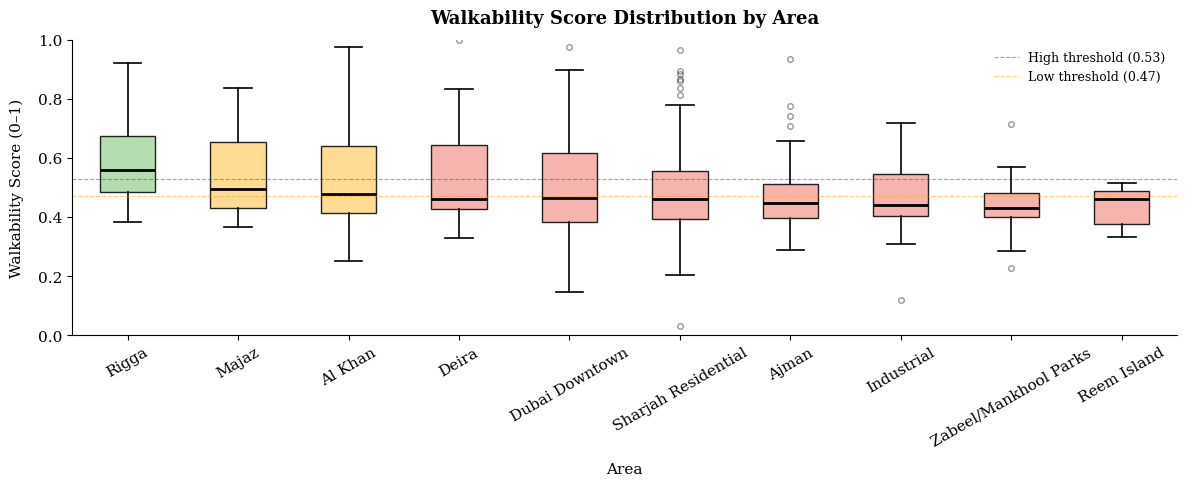

In [43]:
fig, ax = plt.subplots(figsize=(12, 5))

data_by_area = [
    df_scores[df_scores["area"] == area]["walkability"].dropna().values
    for area in AREA_ORDER
]

bp = ax.boxplot(
    data_by_area,
    labels=AREA_ORDER,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=4, alpha=0.4),
)

medians = [np.median(d) for d in data_by_area]
for patch, median in zip(bp["boxes"], medians):
    if median >= 0.53:
        patch.set_facecolor("#A8D5A2")
    elif median >= 0.47:
        patch.set_facecolor("#FFD580")
    else:
        patch.set_facecolor("#F4A8A0")
    patch.set_alpha(0.85)

ax.set_xlabel("Area", labelpad=10)
ax.set_ylabel("Walkability Score (0–1)", labelpad=10)
ax.set_title("Walkability Score Distribution by Area", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 1)
ax.axhline(0.53, color="green",  linestyle="--", linewidth=0.8, alpha=0.5, label="High threshold (0.53)")
ax.axhline(0.47, color="orange", linestyle="--", linewidth=0.8, alpha=0.5, label="Low threshold (0.47)")
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("plot1_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

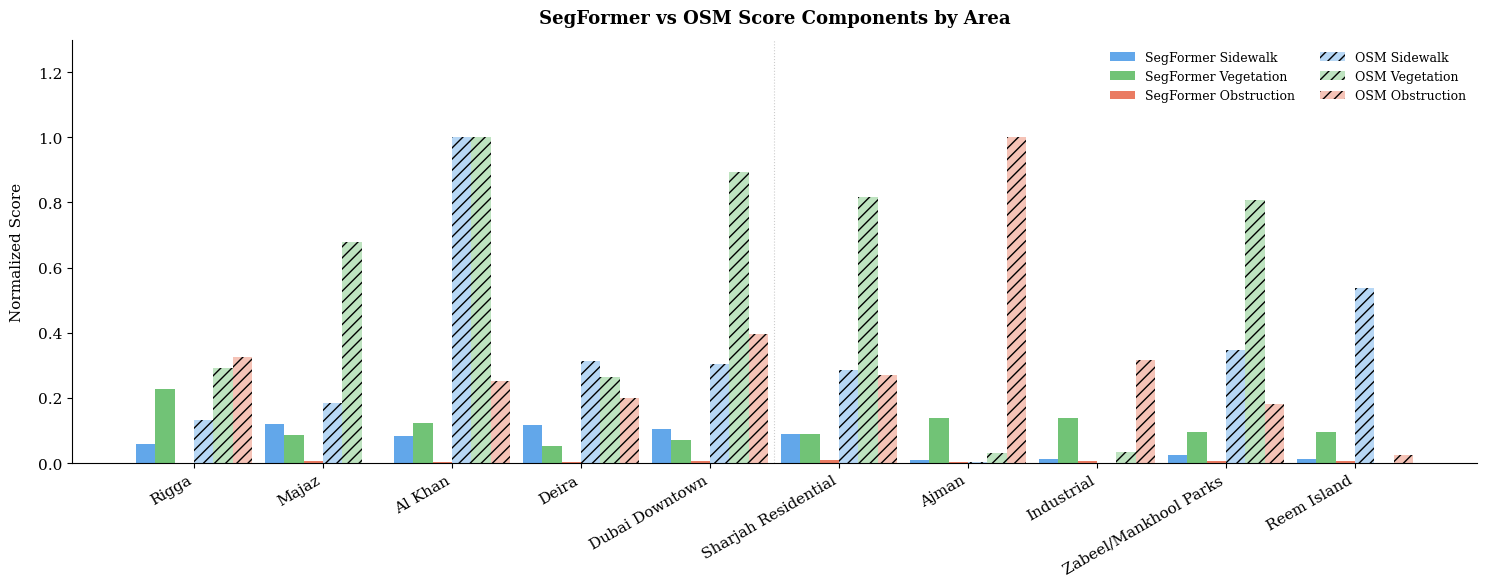

In [39]:
df_summary = df_scores.groupby("area").agg(
    avg_sidewalk    = ("r_sidewalk",    "mean"),
    avg_vegetation  = ("r_vegetation",  "mean"),
    avg_obstruction = ("r_obstruction", "mean"),
).reindex(AREA_ORDER).reset_index()

# Merge OSM normalized components
df_osm_components = df_classes[["area", "osm_sidewalk_norm", "osm_veg_norm", "osm_barrier_norm"]].copy()
df_osm_components["area"] = df_osm_components["area"].replace("Park", "Zabeel/Mankhool Parks")
df_summary = df_summary.merge(df_osm_components, on="area", how="left")

x     = np.arange(len(AREA_ORDER))
width = 0.15  # narrower to fit 6 bars

fig, ax = plt.subplots(figsize=(15, 6))

# SegFormer bars
ax.bar(x - 2.5*width, df_summary["avg_sidewalk"],    width, label="SegFormer Sidewalk",    color="#4C9BE8", alpha=0.88)
ax.bar(x - 1.5*width, df_summary["avg_vegetation"],  width, label="SegFormer Vegetation",  color="#5DBB63", alpha=0.88)
ax.bar(x - 0.5*width, df_summary["avg_obstruction"], width, label="SegFormer Obstruction", color="#E8694C", alpha=0.88)

# OSM bars
ax.bar(x + 0.5*width, df_summary["osm_sidewalk_norm"], width, label="OSM Sidewalk",    color="#4C9BE8", alpha=0.40, hatch="///")
ax.bar(x + 1.5*width, df_summary["osm_veg_norm"],      width, label="OSM Vegetation",  color="#5DBB63", alpha=0.40, hatch="///")
ax.bar(x + 2.5*width, df_summary["osm_barrier_norm"],  width, label="OSM Obstruction", color="#E8694C", alpha=0.40, hatch="///")

ax.set_xticks(x)
ax.set_xticklabels(AREA_ORDER, rotation=30, ha="right")
ax.set_ylabel("Normalized Score", labelpad=10)
ax.set_title("SegFormer vs OSM Score Components by Area", fontsize=13, fontweight="bold", pad=12)
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.set_ylim(0, df_summary[["avg_sidewalk", "avg_vegetation", "avg_obstruction",
                            "osm_sidewalk_norm", "osm_veg_norm", "osm_barrier_norm"]].max().max() * 1.3)

# Divider between SegFormer and OSM groups
ax.axvline(x=len(AREA_ORDER)/2 - 0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.savefig("plot2_components.png", dpi=300, bbox_inches="tight")
plt.show()

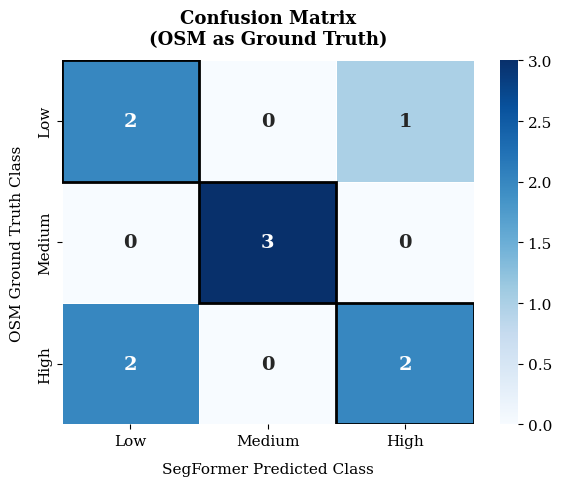

In [31]:
y_true = df_classes["osm_class"].astype(str)
y_pred = df_classes["segformer_class"].astype(str)
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 14, "weight": "bold"},
)

ax.set_xlabel("SegFormer Predicted Class", labelpad=10)
ax.set_ylabel("OSM Ground Truth Class",   labelpad=10)
ax.set_title("Confusion Matrix\n(OSM as Ground Truth)", fontsize=13, fontweight="bold", pad=12)

for i in range(len(labels)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="black", linewidth=2))

plt.tight_layout()
plt.savefig("plot4_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
print(df_classes.columns.tolist())

['area', 'avg_walkability', 'avg_sidewalk', 'avg_vegetation', 'sidewalk_coverage_%', 'vegetation_features', 'barrier_features', 'bbox_area', 'veg_per_area', 'barrier_per_area', 'osm_sidewalk_norm', 'osm_veg_norm', 'osm_barrier_norm', 'osm_raw_score', 'osm_score', 'segformer_class', 'osm_class']


In [45]:
print(df_scores.columns.tolist())

['image_id', 'r_sidewalk', 'r_vegetation', 'r_obstruction', 'raw_score', 'walkability', 'longitude', 'latitude', 'bbox', 'area']


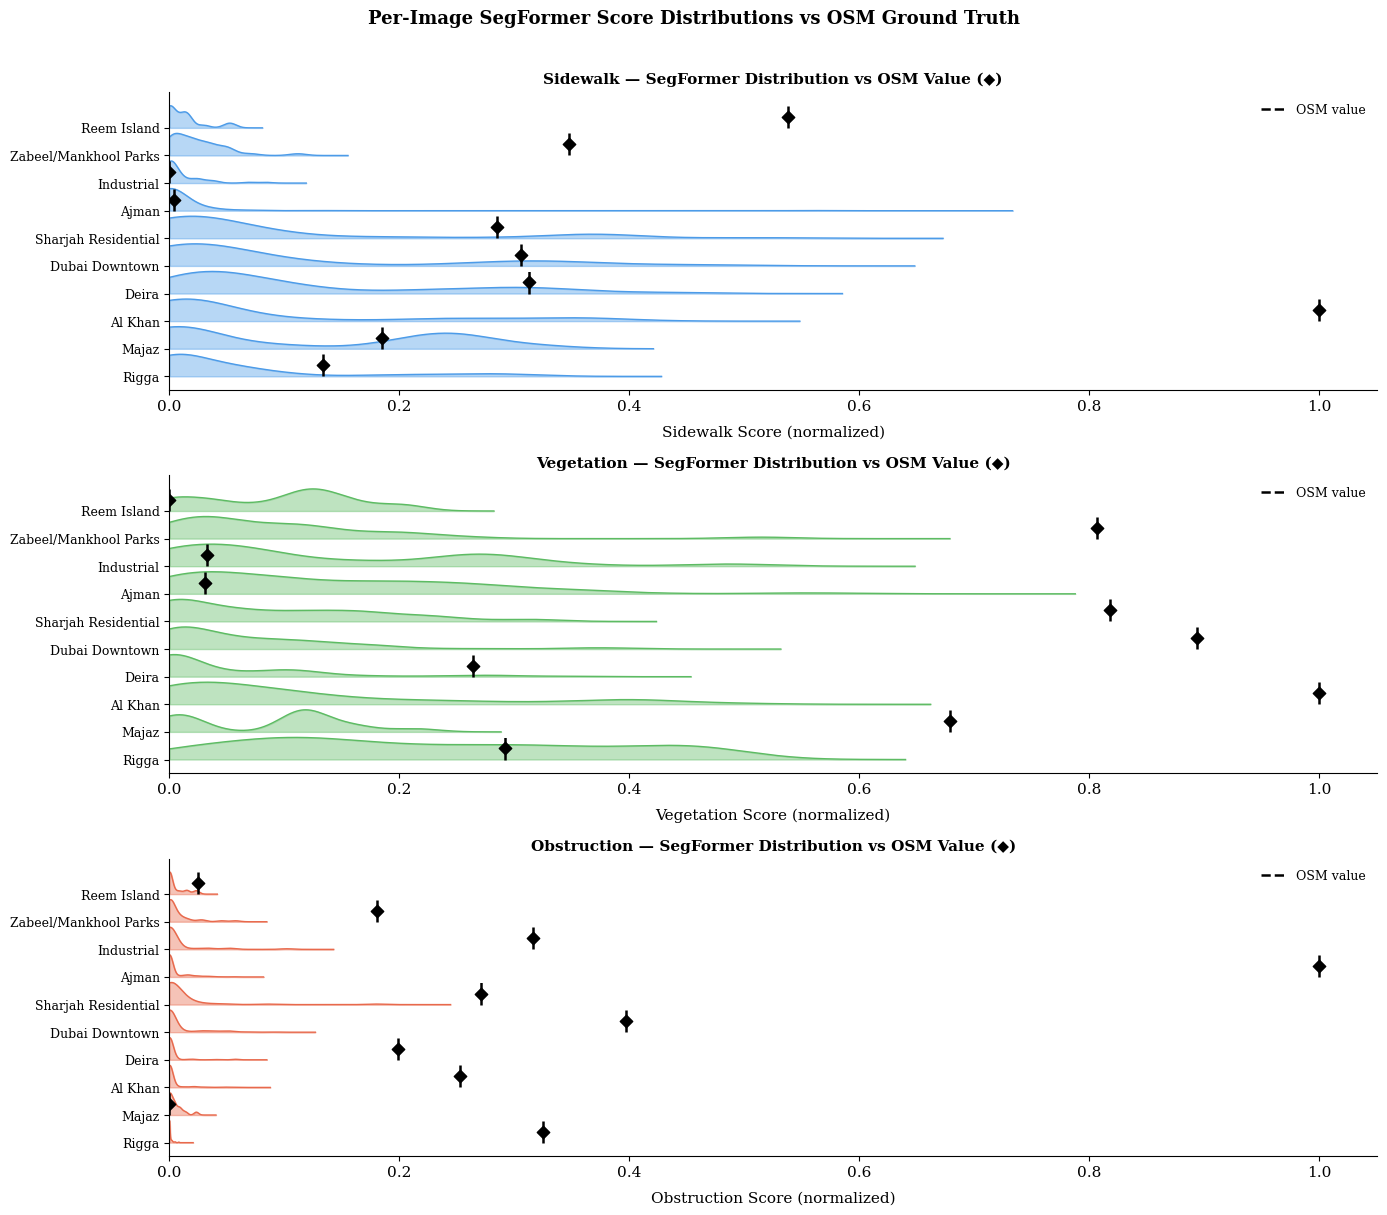

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

components = [
    ("r_sidewalk",    "osm_sidewalk_norm", "Sidewalk",    "#4C9BE8"),
    ("r_vegetation",  "osm_veg_norm",      "Vegetation",  "#5DBB63"),
    ("r_obstruction", "osm_barrier_norm",  "Obstruction", "#E8694C"),
]

for ax, (seg_col, osm_col, label, color) in zip(axes, components):

    for i, area in enumerate(AREA_ORDER):
        area_data = df_scores[df_scores["area"] == area][seg_col].dropna().values

        # Plot distribution as KDE
        from scipy.stats import gaussian_kde
        if len(area_data) > 1:
            kde_x = np.linspace(0, area_data.max() * 1.3 + 0.01, 300)
            kde   = gaussian_kde(area_data, bw_method=0.3)
            kde_y = kde(kde_x)
            # Normalize KDE height so all areas are comparable
            kde_y = kde_y / kde_y.max() * 0.8
            ax.fill_between(kde_x, i, i + kde_y, alpha=0.4, color=color)
            ax.plot(kde_x, i + kde_y, color=color, linewidth=1)

        # OSM vertical line for this area
        osm_val = df_classes.loc[df_classes["area"] == area, osm_col].values
        if len(osm_val) > 0:
            ax.vlines(
                osm_val[0], i, i + 0.8,
                color="black", linewidth=1.8,
                linestyle="--", zorder=5,
                label="OSM value" if i == 0 else None,
            )
            ax.scatter(
                osm_val[0], i + 0.4,
                marker="D", color="black", s=40, zorder=6,
            )

    ax.set_yticks(range(len(AREA_ORDER)))
    ax.set_yticklabels(AREA_ORDER, fontsize=9)
    ax.set_xlabel(f"{label} Score (normalized)", labelpad=8)
    ax.set_title(f"{label} — SegFormer Distribution vs OSM Value (◆)",
                 fontsize=11, fontweight="bold")
    ax.set_xlim(0, None)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=9, frameon=False, loc="upper right")

plt.suptitle("Per-Image SegFormer Score Distributions vs OSM Ground Truth",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pip install jupyter